## Objective
Introduce pos_weight into BCEWithLogitsLoss to address class imbalance, keeping all
other settings identical to experiment 01. Isolates the effect of loss reweighting alone.
 
## Architecture Changes
 
| Component | 01. Baseline | 02. Baseline Weighted |
|---|---|---|
| Pretrained | False | False |
| Frozen backbone | False | False |
| Hidden dim | 0 | 0 |
| Dropout | 0.0 | 0.0 |
| Pos weight | None | **nevus / melanoma** |
| Optimiser | AdamW | AdamW |
| Weight decay | 1e-4 | 1e-4 |
| LR | 1e-3 | 1e-3 |
| Epochs | 30 | 30 |
 
## Hypothesis
Without pos_weight the model ignores the minority class (melanoma). Reweighting the
loss by the class-frequency ratio forces the model to penalise melanoma misclassification
more heavily, improving recall and F2 at the cost of some overall accuracy — the only
change from experiment 01.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path
 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
 
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))
 
from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.densenet import get_densenet121
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
 
import pandas as pd
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
 
set_seed(42)
 
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
 
_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)
 
train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_densenet121(
    num_classes=1,
    pretrained=False,
    freeze_backbone=False,
    dropout=0.0,
    hidden_dim=0,
).to(device)
 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
 
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
 
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)
 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print('Pretrained: False | Frozen: False | Dropout: 0.0 | Hidden dim: 0 | Pos weight: enabled')

Trainable params: 6,954,881 / 6,954,881
Pretrained: False | Frozen: False | Dropout: 0.0 | Hidden dim: 0 | Pos weight: enabled


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []
 
for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)
 
    scheduler.step()
 
    train_history.append(train_metrics)
    val_history.append(val_metrics)
 
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")
 
    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/densenet121_baseline_weighted_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/30]
  Train | Loss: 1.1357, Bal Acc: 0.6302, Recall: 0.7172, F2: 0.4257, AUC: 0.6808
  Val   | Loss: 1.1934, Bal Acc: 0.6548, Recall: 0.5339, F2: 0.4283, AUC: 0.7219
  -> Saved best model (val AUC: 0.7219)


Epoch [2/30]
  Train | Loss: 1.0838, Bal Acc: 0.6588, Recall: 0.7332, F2: 0.4523, AUC: 0.7216
  Val   | Loss: 1.0360, Bal Acc: 0.7197, Recall: 0.8941, F2: 0.5361, AUC: 0.7985
  -> Saved best model (val AUC: 0.7985)


Epoch [3/30]
  Train | Loss: 1.0892, Bal Acc: 0.6760, Recall: 0.7263, F2: 0.4678, AUC: 0.7357
  Val   | Loss: 0.9801, Bal Acc: 0.7136, Recall: 0.6525, F2: 0.5130, AUC: 0.8095
  -> Saved best model (val AUC: 0.8095)


Epoch [4/30]
  Train | Loss: 0.9883, Bal Acc: 0.7085, Recall: 0.7640, F2: 0.5041, AUC: 0.7801
  Val   | Loss: 0.9535, Bal Acc: 0.7267, Recall: 0.9449, F2: 0.5450, AUC: 0.8239
  -> Saved best model (val AUC: 0.8239)


Epoch [5/30]
  Train | Loss: 0.9652, Bal Acc: 0.7250, Recall: 0.7925, F2: 0.5233, AUC: 0.7946
  Val   | Loss: 0.9366, Bal Acc: 0.7269, Recall: 0.9364, F2: 0.5449, AUC: 0.8247
  -> Saved best model (val AUC: 0.8247)


...

Epoch [26/30]
  Train | Loss: 0.8188, Bal Acc: 0.7750, Recall: 0.8575, F2: 0.5831, AUC: 0.8559
  Val   | Loss: 0.8530, Bal Acc: 0.7605, Recall: 0.8644, F2: 0.5789, AUC: 0.8480


Epoch [27/30]
  Train | Loss: 0.7979, Bal Acc: 0.7798, Recall: 0.8643, F2: 0.5891, AUC: 0.8606
  Val   | Loss: 0.8408, Bal Acc: 0.7611, Recall: 0.8814, F2: 0.5797, AUC: 0.8515
  -> Saved best model (val AUC: 0.8515)


Epoch [28/30]
  Train | Loss: 0.8102, Bal Acc: 0.7782, Recall: 0.8575, F2: 0.5873, AUC: 0.8545
  Val   | Loss: 0.8483, Bal Acc: 0.7595, Recall: 0.8602, F2: 0.5777, AUC: 0.8477


Epoch [29/30]
  Train | Loss: 0.7935, Bal Acc: 0.7788, Recall: 0.8597, F2: 0.5880, AUC: 0.8613
  Val   | Loss: 0.8560, Bal Acc: 0.7567, Recall: 0.8686, F2: 0.5746, AUC: 0.8468


Epoch [30/30]
  Train | Loss: 0.8083, Bal Acc: 0.7766, Recall: 0.8586, F2: 0.5852, AUC: 0.8540
  Val   | Loss: 0.8550, Bal Acc: 0.7611, Recall: 0.9025, F2: 0.5797, AUC: 0.8483


## Plot Train and Validation Curves


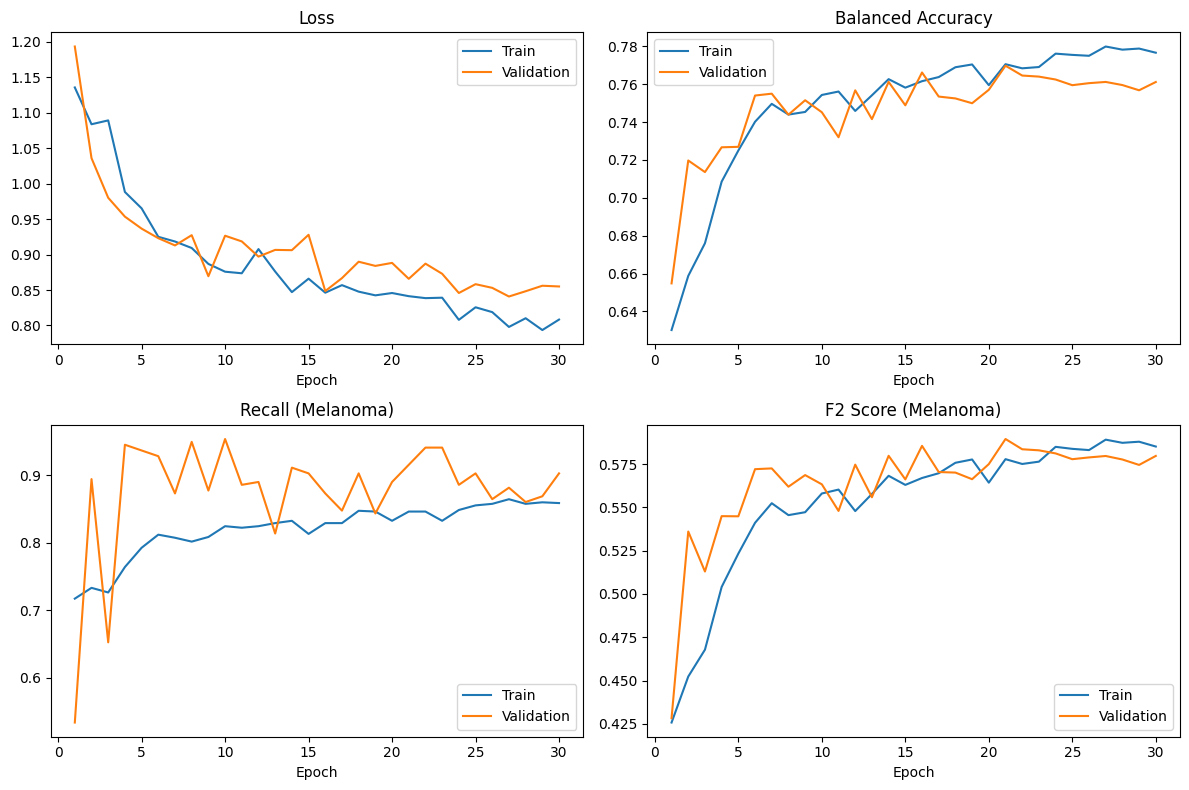

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/densenet121_baseline_weighted_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

C:\Users\1008462\AppData\Local\Temp\ipykernel_33948\1685461050.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(ROOT / 'models/densen

Best threshold: 0.54 | Val F2: 0.5934


## Test Set Evaluation

Threshold:          0.54
AUC-ROC:            0.8531
Balanced Accuracy:  0.7706
F2 Score:           0.5837

              precision    recall  f1-score   support

Non-Melanoma     0.9787    0.6522    0.7828      1340
    Melanoma     0.2460    0.8889    0.3853       171

    accuracy                         0.6790      1511
   macro avg     0.6123    0.7706    0.5841      1511
weighted avg     0.8958    0.6790    0.7378      1511



C:\Users\1008462\Desktop\50.021_project_group4\venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


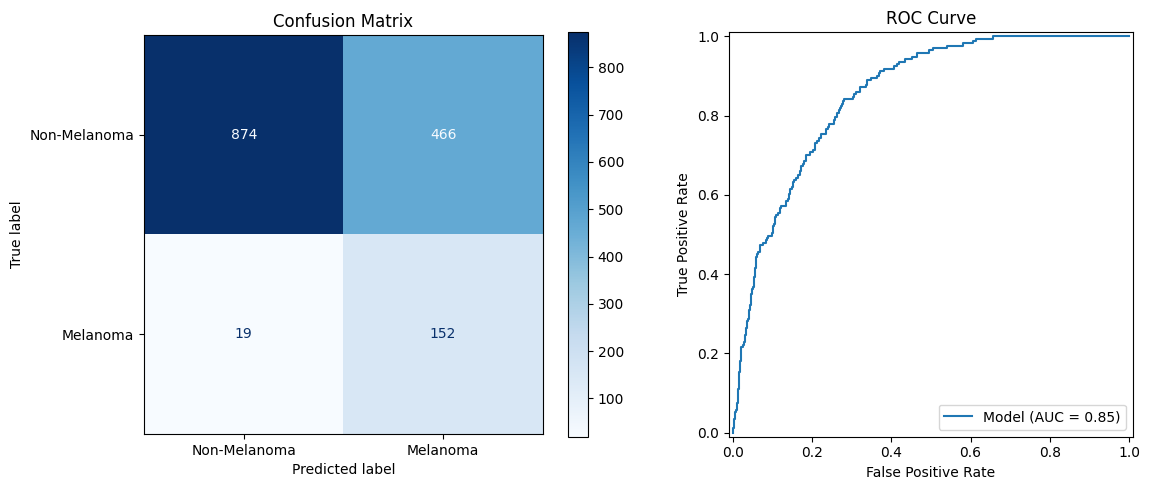

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)